# Guided DDIM Reconstruction for Time-Resolved 4D CT

This notebook tests a trained **ladiff** diffusion model (trained with
`train_time_resolved.py` on `TifVolumeSliceDataset`) using the DDIM pipeline
with sinogram guidance.

**Pipeline overview:**
1. Load one or more 2D slices from a TIFF volume (ground truth).
2. Forward-project each slice to obtain a **full** sinogram.
3. Extract a **limited-angle** subset of projections (configurable range & count).
4. Reconstruct a **limited-angle FBP** baseline.
5. Run DDIM with sinogram guidance using only the limited-angle projections.
6. Compare the guided reconstruction to the ground truth (PSNR, SSIM).

## 1. Imports and Setup

In [1]:
import sys, time, json, importlib
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch

# ── Project paths ─────────────────────────────────────────────────────────
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
sys.path.insert(0, '/myhome/astra-torch')
sys.path.insert(0, '/myhome/chip-project')

import lovely_tensors as lt
lt.monkey_patch()

# ── Dataset ────────────────────────────────────────────────────────────────
from ladiff.datasets import TifVolumeSliceDataset

# ── Diffusion pipeline ─────────────────────────────────────────────────────
from ladiff.schedulers.scheduling_ddim import GuidedDDIMScheduler
from ladiff.schedulers.pipeline_ddim import DDIMPipeline

# ── Reconstruction (2D parallel beam via lamino with angle=0) ─────────────
from astra_torch.lamino import (
    fbp_reconstruction_masked,
    gd_reconstruction_masked,
    build_lamino_projector,
)

# ── Diffusion model ────────────────────────────────────────────────────────
from diffusers.models import UNet2DModel

# ── Metrics ────────────────────────────────────────────────────────────────
from skimage.metrics import peak_signal_noise_ratio as compute_psnr
from skimage.metrics import structural_similarity as compute_ssim

# ── Laminography angle for standard 2D parallel-beam CT ───────────────────
LAMINO_ANGLE_DEG = 0.0

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['image.cmap'] = 'gray'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}  |  PyTorch {torch.__version__}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name()}")

zarr not installed


/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda  |  PyTorch 2.8.0+cu128
GPU: NVIDIA A100 80GB PCIe


In [2]:
# ── Circular mask for metrics ──────────────────────────────────────────────
def make_circular_mask(h: int, w: int, radius: float = None) -> np.ndarray:
    """Return a boolean circular mask of shape (h, w) with given radius centered on the image."""
    if radius is None:
        radius = w / 2.0
    cy, cx = h / 2.0, w / 2.0
    Y, X = np.ogrid[:h, :w]
    return ((X - cx) ** 2 + (Y - cy) ** 2) <= radius ** 2


def masked_psnr(gt: torch.Tensor, pred: torch.Tensor, mask: torch.Tensor, data_range: float) -> float:
    """Compute PSNR only within the True region of *mask*."""
    mse = torch.mean((gt[:, mask] - pred[:, mask]) ** 2)
    if mse == 0:
        return float('inf')
    return 10.0 * torch.log10(data_range ** 2 / mse)


def masked_ssim(gt: torch.Tensor, pred: torch.Tensor, mask: torch.Tensor, data_range: float) -> float:
    """Compute SSIM using skimage, but only report the mean over the masked region."""
    # gt is a volume so we need to average SSIM over slices
    ssim_values = []
    for i in range(gt.shape[0]):
        ssim_value, _ = compute_ssim(gt[i, mask].cpu().numpy(), pred[i, mask].cpu().numpy(), data_range=data_range, full=True)
        ssim_values.append(ssim_value)
    return float(np.mean(ssim_values))


print("Circular-mask metric helpers defined ✅")

Circular-mask metric helpers defined ✅


## 2. Configuration

In [3]:
# ── Data ──────────────────────────────────────────────────────────────────
# DATA_PATH = Path('/myhome/data/sdate/shared/time_resolved/212_Wunderkerze2/timesteps/212_Wunderkerze2_rotate_04280.tif')
DATA_PATH = Path('/myhome/data/sdate/shared/time_resolved/149_ASM_SP_1ktps/timesteps/149_ASM_SP_1ktps_rotate_35711.tif')
FILE_RANGE = 5          # number of consecutive tif files to load (1 = current only, 3 or 5 = with neighbors)
IMAGE_SIZE = 256         # native resolution (no resize)


# ── Full-angle projections (for GT reconstruction baseline) ───────────────
NUM_FULL_PROJS  = 1000    # number of projections over 0-180°
FULL_ANGLE_START = 0.0
FULL_ANGLE_END   = 180.0

# ── Limited-angle projection geometry ─────────────────────────────────────
ANGLE_START_DEG = 0.0    # start of the limited angular range for the *first* frame
ANGLE_RANGE_DEG = 36.0   # angular range per frame
# Each frame i covers [ANGLE_START_DEG + i*ANGLE_RANGE_DEG, ANGLE_START_DEG + (i+1)*ANGLE_RANGE_DEG]
# The middle frame (gt frame) index = FILE_RANGE // 2

# Number of limited-angle projections per frame (proportional to angular range)
NUM_LA_PROJS = int(ANGLE_RANGE_DEG * NUM_FULL_PROJS / (FULL_ANGLE_END - FULL_ANGLE_START))

# ── CT geometry ───────────────────────────────────────────────────────────
DET_SPACING_MM = 1.0

# ── Test slice ─────────────────────────────────────────────────────────────
TEST_SLICE_IDX = 64      # which slice within the dataset to test

# ── Model ─────────────────────────────────────────────────────────────────
# CHECKPOINT_PATH = str(project_root / 'checkpoints' / 'Wunderkerze_time_resolved.pt')
CHECKPOINT_PATH = str(project_root / 'checkpoints' / 'ASM_SP_1ktps_time_resolved.pt')

# ── Normalization ─────────────────────────────────────────────────────────
# Load normalisation from checkpoint sidecar
NORM_MIN, NORM_MAX = 0.0, 233.0  # default values if no config found
norm_config_path = Path(CHECKPOINT_PATH.replace('.pt', '_norm.json'))
if norm_config_path.exists():
    with open(norm_config_path) as f:
        nc = json.load(f)
    NORM_MIN = float(nc.get('norm_min', 0.0))
    NORM_MAX = float(nc.get('norm_max', 233.0))
    print(f"  Loaded norm config from {norm_config_path}")
else:
    print(f"  ⚠ No norm config found at {norm_config_path} — using [0, {NORM_MAX}] as default")

print(f"  Norm range: [{NORM_MIN:.4g}, {NORM_MAX:.4g}]")

# Normalisation functions: dataset already normalises to [0,1]
# The diffusion model was trained on [0,1] data, so normalize_fn/denormalize_fn are identity.
normalize_fn   = lambda x: x
denormalize_fn = lambda x: x


print("\nConfiguration set ✅")
print(f"  Data:          {DATA_PATH.name}")
print(f"  File range:    {FILE_RANGE}")
print(f"  Image size:    {IMAGE_SIZE}")
print(f"  Angle range:   {ANGLE_RANGE_DEG}° per frame")
print(f"  LA projs/frame:{NUM_LA_PROJS}")
print(f"  Full angles:   {FULL_ANGLE_START}° – {FULL_ANGLE_END}° ({NUM_FULL_PROJS} projections)")
print(f"  Test slice:    {TEST_SLICE_IDX}")
print(f"  Checkpoint:    {CHECKPOINT_PATH}")

  Loaded norm config from /myhome/sdate/checkpoints/ASM_SP_1ktps_time_resolved_norm.json
  Norm range: [0, 233]

Configuration set ✅
  Data:          149_ASM_SP_1ktps_rotate_35711.tif
  File range:    5
  Image size:    256
  Angle range:   36.0° per frame
  LA projs/frame:200
  Full angles:   0.0° – 180.0° (1000 projections)
  Test slice:    64
  Checkpoint:    /myhome/sdate/checkpoints/ASM_SP_1ktps_time_resolved.pt


## 3. Load Test Data

TifVolumeSliceDataset(files=5, total_slices=600, slices_per_file=[120, 120, 120, 120, 120], image_size=256×256, norm=[0, 233])

Loaded 5 files, middle (gt) file index = 2
  [0] 149_ASM_SP_1ktps_rotate_35711.tif
  [1] 149_ASM_SP_1ktps_rotate_35712.tif
  [2] 149_ASM_SP_1ktps_rotate_35713.tif ← GT
  [3] 149_ASM_SP_1ktps_rotate_35714.tif
  [4] 149_ASM_SP_1ktps_rotate_35715.tif

GT slice 10: shape=torch.Size([256, 256]), range=[0.0000, 0.8262]


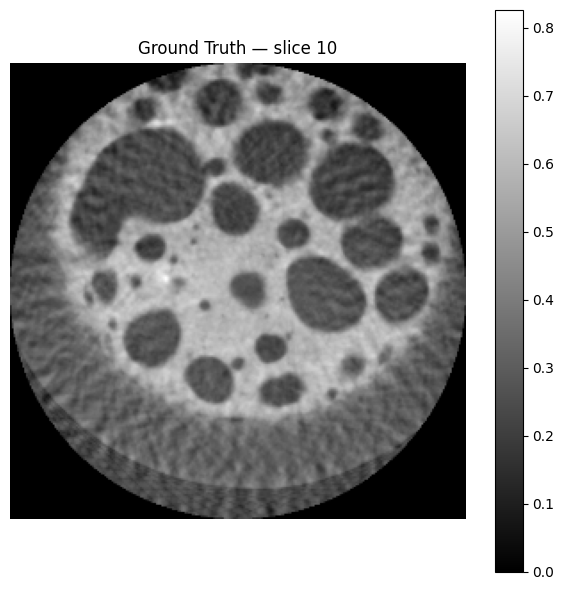

In [4]:
TEST_SLICE_IDX = 10
dataset = TifVolumeSliceDataset(
    data_path=DATA_PATH,
    file_range=FILE_RANGE if FILE_RANGE > 0 else None,
    resize=IMAGE_SIZE,  # downsample to IMAGE_SIZE x IMAGE_SIZE for faster testing
    normalize_range=(NORM_MIN, NORM_MAX) if (NORM_MIN != 0.0 or NORM_MAX != 1.0) else None,
    augment=False,  # no augmentation for testing
)
print(dataset)

# The middle file is the "current" frame we care about
mid_idx = dataset.num_files // 2
print(f"\nLoaded {dataset.num_files} files, middle (gt) file index = {mid_idx}")
for i, f in enumerate(dataset.files):
    tag = " ← GT" if i == mid_idx else ""
    print(f"  [{i}] {f.name}{tag}")

# Ground truth: the original 2D slice from the middle volume (already normalised to [0,1])
gt_slice = dataset[sum(dataset.slices_per_file[:mid_idx]) + TEST_SLICE_IDX]
print(f"\nGT slice {TEST_SLICE_IDX}: shape={gt_slice.shape}, "
      f"range=[{gt_slice.min():.4f}, {gt_slice.max():.4f}]")

plt.figure(figsize=(6, 6))
plt.imshow(gt_slice.numpy(), cmap='gray')
plt.title(f'Ground Truth — slice {TEST_SLICE_IDX}')
# add colorbar with correct scaling
plt.colorbar()
plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Generate Projections from Ground Truth

Use the ASTRA parallel-beam laminography projector (`lamino_angle=0°`) to
forward-project each loaded volume into sinograms.

Each frame *i* uses a **rotating limited-angle window**:
frame *i* covers `[ANGLE_START_DEG + i*ANGLE_RANGE_DEG, ANGLE_START_DEG + (i+1)*ANGLE_RANGE_DEG]`.

- **Full sinogram** (0°–180°) of the middle (GT) frame for FBP ground-truth reconstruction.
- **Per-frame limited-angle sinograms** for guidance.
- **Combined (sliding-window) sinogram** concatenating all frames' limited-angle projections.

  Volume [0]: torch.Size([120, 256, 256])  range=[0.0000, 0.8821]
  Volume [1]: torch.Size([120, 256, 256])  range=[0.0000, 0.8752]
  Volume [2]: torch.Size([120, 256, 256])  range=[0.0000, 0.8808]
  Volume [3]: torch.Size([120, 256, 256])  range=[0.0000, 0.8732]
  Volume [4]: torch.Size([120, 256, 256])  range=[0.0000, 0.8755]

Full sinogram (GT): torch.Size([1000, 120, 256])  range=[3.3867, 132.0453]
  Frame [0] LA: 0.0°–36.0° (200 projs)  sino=torch.Size([200, 120, 256])  range=[3.4908, 132.2477]
  Frame [1] LA: 36.0°–72.0° (200 projs)  sino=torch.Size([200, 120, 256])  range=[4.3305, 128.9840]
  Frame [2] LA: 72.0°–108.0° (200 projs)  sino=torch.Size([200, 120, 256])  range=[4.2977, 126.6352]
  Frame [3] LA: 108.0°–144.0° (200 projs)  sino=torch.Size([200, 120, 256])  range=[4.2968, 126.4902]
  Frame [4] LA: 144.0°–180.0° (200 projs)  sino=torch.Size([200, 120, 256])  range=[3.6972, 133.7232]

Middle frame LA sinogram: torch.Size([200, 120, 256])
Sliding-window sinogram:  torch.Siz

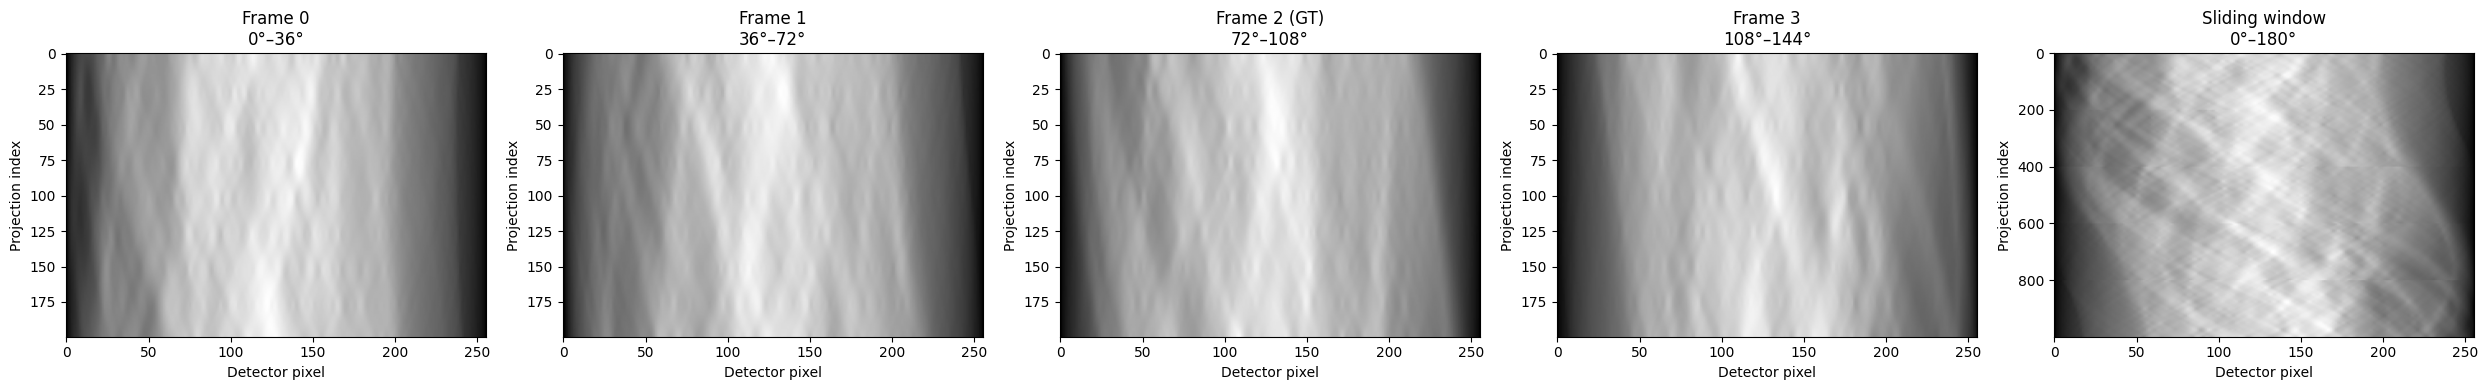

In [5]:
mid_idx = dataset.num_files // 2
num_frames = dataset.num_files

# ── Load all volumes ────────────────────────────────────────────────────────
volumes = []
for i in range(num_frames):
    volumes.append(dataset.get_volume(i).to(device))
    print(f"  Volume [{i}]: {volumes[-1].shape}  range=[{volumes[-1].min():.4f}, {volumes[-1].max():.4f}]")

gt = volumes[mid_idx]  # (D, H, W) — the middle frame is our ground truth
D, H, W = gt.shape

# ── Full-angle projections (only for GT frame) ─────────────────────────────
full_angles_deg = torch.linspace(FULL_ANGLE_START, FULL_ANGLE_END, NUM_FULL_PROJS).numpy()

full_projector = build_lamino_projector(
    vol_shape=gt.shape, det_shape=(D, W), angles_deg=full_angles_deg,
    lamino_angle_deg=LAMINO_ANGLE_DEG, det_spacing_mm=DET_SPACING_MM, device=device,
)
gt_vol = gt.unsqueeze(0).unsqueeze(0)
with torch.no_grad():
    full_sino = full_projector(gt_vol).squeeze(0)

print(f"\nFull sinogram (GT): {full_sino.shape}  range=[{full_sino.min():.4f}, {full_sino.max():.4f}]")

# ── Per-frame limited-angle projections ────────────────────────────────────
# Frame i covers [ANGLE_START_DEG + i*ANGLE_RANGE_DEG, ANGLE_START_DEG + (i+1)*ANGLE_RANGE_DEG]
frame_la_angles = []   # list of numpy arrays, one per frame
frame_la_sinos  = []   # list of (V_la, R, C) tensors, one per frame

for i in range(num_frames):
    a_start = ANGLE_START_DEG + i * ANGLE_RANGE_DEG
    a_end   = ANGLE_START_DEG + (i + 1) * ANGLE_RANGE_DEG
    angles  = torch.linspace(a_start, a_end, NUM_LA_PROJS).numpy()
    frame_la_angles.append(angles)

    la_proj = build_lamino_projector(
        vol_shape=volumes[i].shape, det_shape=(D, W), angles_deg=angles,
        lamino_angle_deg=LAMINO_ANGLE_DEG, det_spacing_mm=DET_SPACING_MM, device=device,
    )
    vol_i = volumes[i].unsqueeze(0).unsqueeze(0)
    with torch.no_grad():
        sino_i = la_proj(vol_i).squeeze(0)
    frame_la_sinos.append(sino_i)
    print(f"  Frame [{i}] LA: {a_start:.1f}°–{a_end:.1f}° ({NUM_LA_PROJS} projs)  "
          f"sino={sino_i.shape}  range=[{sino_i.min():.4f}, {sino_i.max():.4f}]")

# ── Middle frame's LA sinogram (for single-frame guidance) ─────────────────
la_sino      = frame_la_sinos[mid_idx]
la_angles_deg = frame_la_angles[mid_idx]

# ── Combined sliding-window sinogram (all frames) ─────────────────────────
sw_sino       = torch.cat(frame_la_sinos, dim=0)           # (V_total, R, C)
sw_angles_deg = np.concatenate(frame_la_angles, axis=0)    # (V_total,)

print(f"\nMiddle frame LA sinogram: {la_sino.shape}")
print(f"Sliding-window sinogram:  {sw_sino.shape}  angles {sw_angles_deg[0]:.1f}°–{sw_angles_deg[-1]:.1f}°")

# Visualise sinograms
n_panels = min(num_frames + 1, 5)
fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 4))
if n_panels == 1:
    axes = [axes]
for i in range(min(num_frames, n_panels - 1)):
    axes[i].imshow(frame_la_sinos[i][:, 0, :].cpu().numpy(), aspect='auto', cmap='gray')
    tag = " (GT)" if i == mid_idx else ""
    axes[i].set_title(f'Frame {i}{tag}\n{frame_la_angles[i][0]:.0f}°–{frame_la_angles[i][-1]:.0f}°')
    axes[i].set_xlabel('Detector pixel')
    axes[i].set_ylabel('Projection index')

axes[-1].imshow(sw_sino[:, 0, :].cpu().numpy(), aspect='auto', cmap='gray')
axes[-1].set_title(f'Sliding window\n{sw_angles_deg[0]:.0f}°–{sw_angles_deg[-1]:.0f}°')
axes[-1].set_xlabel('Detector pixel')
axes[-1].set_ylabel('Projection index')

plt.tight_layout()
plt.show()

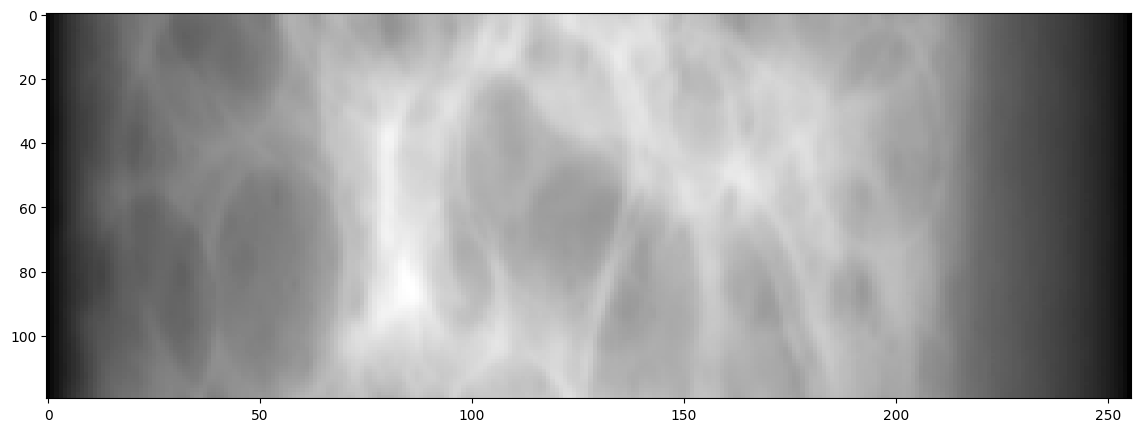

In [7]:
plt.imshow(la_sino[0].cpu().numpy(), aspect='auto', cmap='gray')

## 5. Baseline Reconstructions: FBP

- **Full-angle FBP**: reference reconstruction from all projections (GT frame only).
- **Limited-angle FBP (LA)**: shows artifacts from the restricted angular range (GT frame only).
- **Sliding-window FBP (SW)**: reconstruction using combined projections from all loaded frames.

Ground Truth: torch.Size([120, 256, 256])  [0.0000, 0.8808]  (0.0s)
Full-angle FBP: torch.Size([120, 256, 256])  [-0.1624, 0.7969]  (0.1s)
LA FBP:         torch.Size([120, 256, 256])  [-1.2357, 1.6715]  (0.0s)
SW FBP:         torch.Size([120, 256, 256])  [-0.1644, 0.7432]  (0.1s)
Circular mask: 46677 pixels out of 65536 (71.2%)


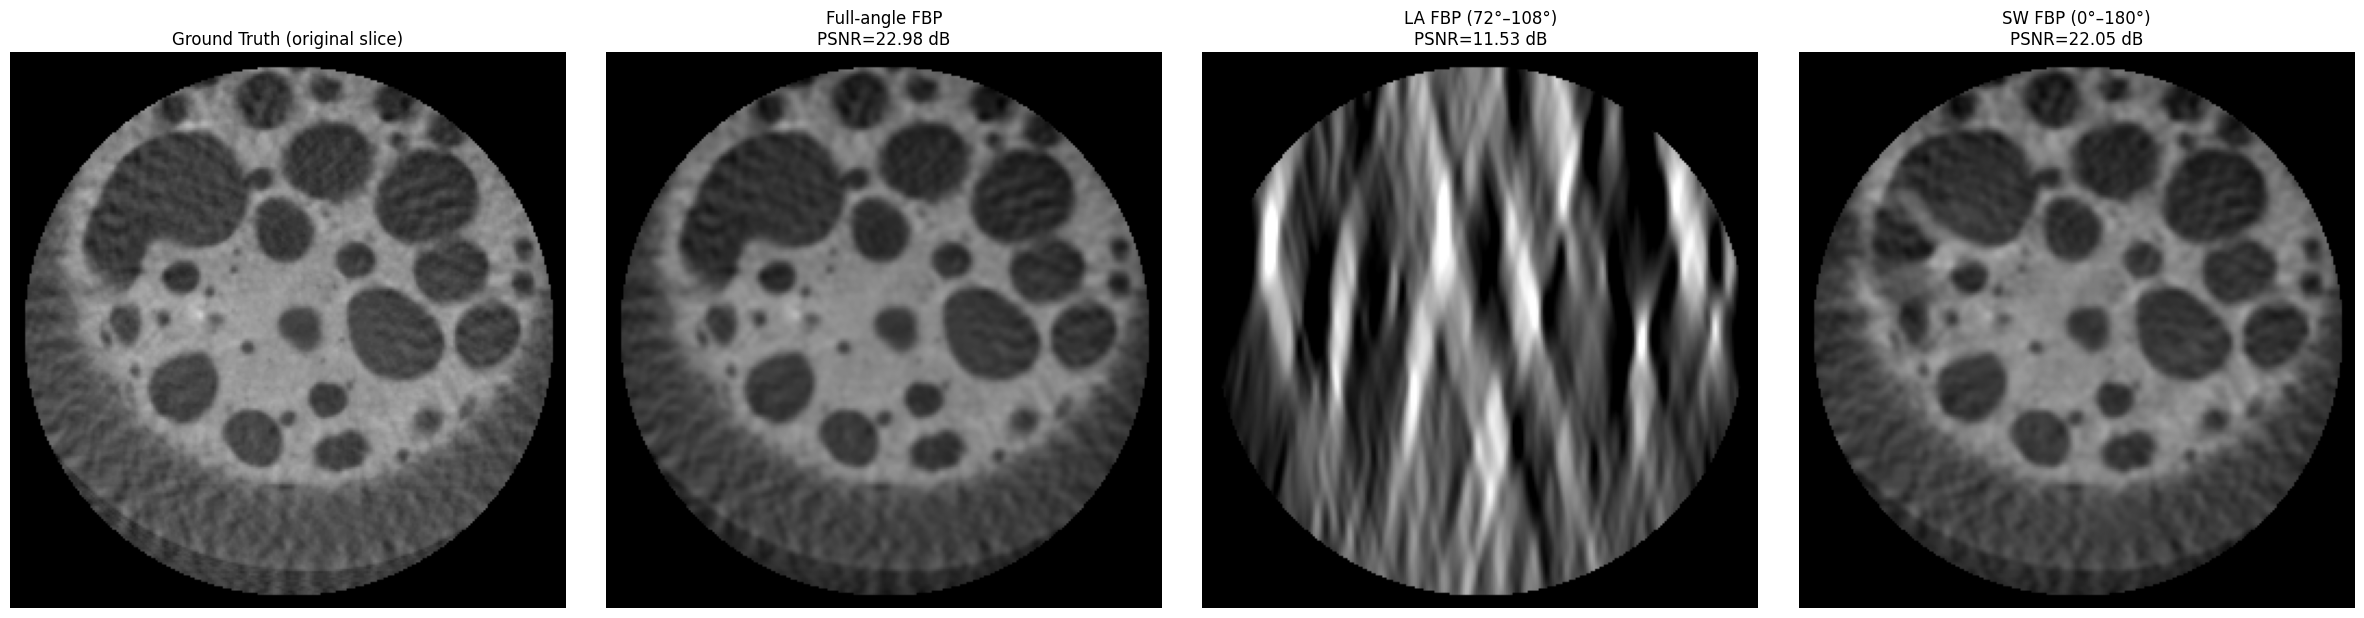

In [6]:
t0 = time.time()
print(f"Ground Truth: {gt.shape}  [{gt.min():.4f}, {gt.max():.4f}]  ({time.time()-t0:.1f}s)")

# ── Full-angle FBP ─────────────────────────────────────────────────────────
gt_fbp = fbp_reconstruction_masked(
    projs_vrc=full_sino,
    angles_deg=full_angles_deg,
    lamino_angle_deg=LAMINO_ANGLE_DEG,
    vol_shape=gt.shape,
    det_spacing_mm=DET_SPACING_MM,
    filter_type='hann',
    device=device,
).squeeze(0)
print(f"Full-angle FBP: {gt_fbp.shape}  [{gt_fbp.min():.4f}, {gt_fbp.max():.4f}]  ({time.time()-t0:.1f}s)")

# ── Limited-angle FBP (middle frame only) ──────────────────────────────────
t0 = time.time()
la_fbp = fbp_reconstruction_masked(
    projs_vrc=la_sino,
    angles_deg=la_angles_deg,
    lamino_angle_deg=LAMINO_ANGLE_DEG,
    vol_shape=gt.shape,
    det_spacing_mm=DET_SPACING_MM,
    filter_type='hann',
    device=device,
).squeeze(0)
print(f"LA FBP:         {la_fbp.shape}  [{la_fbp.min():.4f}, {la_fbp.max():.4f}]  ({time.time()-t0:.1f}s)")

# ── Sliding-window FBP (all frames combined) ──────────────────────────────
t0 = time.time()
if num_frames > 1:
    sw_fbp = fbp_reconstruction_masked(
        projs_vrc=sw_sino,
        angles_deg=sw_angles_deg,
        lamino_angle_deg=LAMINO_ANGLE_DEG,
        vol_shape=gt.shape,
        det_spacing_mm=DET_SPACING_MM,
        filter_type='hann',
        device=device,
    ).squeeze(0)
    print(f"SW FBP:         {sw_fbp.shape}  [{sw_fbp.min():.4f}, {sw_fbp.max():.4f}]  ({time.time()-t0:.1f}s)")
else:
    sw_fbp = la_fbp
    print(f"SW FBP:         same as LA FBP (single frame)")

# ── Circular mask for metric evaluation ────────────────────────────────────
circ_mask = make_circular_mask(H, W, radius=W / 2.1)  # slightly smaller than W/2 to avoid edge artifacts
circ_mask = torch.tensor(circ_mask, device=device)
print(f"Circular mask: {circ_mask.sum()} pixels out of {H * W} ({100 * circ_mask.float().mean():.1f}%)")

sw_fbp *= circ_mask
la_fbp *= circ_mask
gt_fbp *= circ_mask
gt *= circ_mask


vmin, vmax = (0, 1)
data_range = (gt[:, circ_mask].max() - gt[:, circ_mask].min()).cpu().item()

n_cols = 4 if num_frames > 1 else 3
fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 6))
axes[0].imshow(gt[TEST_SLICE_IDX].cpu(), cmap='gray', vmin=vmin, vmax=vmax)
axes[0].set_title('Ground Truth (original slice)')
axes[0].axis('off')

axes[1].imshow(gt_fbp[TEST_SLICE_IDX].cpu(), cmap='gray', vmin=vmin, vmax=vmax)
psnr_full = masked_psnr(gt, gt_fbp, circ_mask, data_range)
axes[1].set_title(f'Full-angle FBP\nPSNR={psnr_full:.2f} dB')
axes[1].axis('off')

axes[2].imshow(la_fbp[TEST_SLICE_IDX].cpu(), cmap='gray', vmin=vmin, vmax=vmax)
psnr_la = masked_psnr(gt, la_fbp, circ_mask, data_range)
a_s, a_e = la_angles_deg[0], la_angles_deg[-1]
axes[2].set_title(f'LA FBP ({a_s:.0f}°–{a_e:.0f}°)\nPSNR={psnr_la:.2f} dB')
axes[2].axis('off')

if num_frames > 1:
    axes[3].imshow(sw_fbp[TEST_SLICE_IDX].cpu(), cmap='gray', vmin=vmin, vmax=vmax)
    psnr_sw = masked_psnr(gt, sw_fbp, circ_mask, data_range)
    axes[3].set_title(f'SW FBP ({sw_angles_deg[0]:.0f}°–{sw_angles_deg[-1]:.0f}°)\nPSNR={psnr_sw:.2f} dB')
    axes[3].axis('off')

plt.tight_layout()
plt.show()

## 6. Load Trained Diffusion Model

In [7]:
channels = (64, 64, 128, 128, 256, 256)
model = UNet2DModel(
    sample_size=IMAGE_SIZE,
    in_channels=1,
    out_channels=1,
    layers_per_block=2,
    block_out_channels=channels,
    down_block_types=(
        "DownBlock2D", "DownBlock2D", "DownBlock2D",
        "DownBlock2D", "AttnDownBlock2D", "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D", "AttnUpBlock2D", "UpBlock2D",
        "UpBlock2D", "UpBlock2D", "UpBlock2D",
    ),
).to(device)

ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f"Model loaded from {CHECKPOINT_PATH}")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  in_channels=1, out_channels=1")

Model loaded from /myhome/sdate/checkpoints/ASM_SP_1ktps_time_resolved.pt
  Parameters: 28,444,929
  in_channels=1, out_channels=1


## 7. Define Guidance Function (2D Parallel Beam)

The guidance function enforces data consistency at each DDIM step by running
a few gradient-descent iterations of `gd_reconstruction_masked`, minimising
the mismatch between the predicted x₀ and the measured limited-angle projections.

In [8]:
def sinogram_guidance(
    projs_vrc: torch.Tensor,       # (V, R=1, C=W)
    angles_deg: np.ndarray,        # (V,)
    vol_init: torch.Tensor,        # (D, H, W) — current denoised estimate
    max_epochs: int = 5,
    lr: float = 0.1,
    batch_size: int = 30,
    regularization_fn=None,        # optional: fn(vol: Tensor[D,H,W]) -> scalar
    verbose: bool = False,
    # ── Sliding-window support ──
    sw_projs_vrc: torch.Tensor = None,   # (V_all, R=1, C=W) — combined projections
    sw_angles_deg: np.ndarray = None,    # (V_all,) — combined angles
    timestep: int = 0,                   # current diffusion timestep
    sw_threshold: int = 100,             # use SW above this timestep
) -> torch.Tensor:
    """Apply GD guidance using limited-angle data.

    If ``sw_projs_vrc`` is provided and ``timestep > sw_threshold``, uses the
    combined sliding-window projections from all frames.  Otherwise, falls back
    to the middle frame's projections only (original behaviour).

    Parameters
    ----------
    projs_vrc : (V_la, 1, W)
        Limited-angle projections of the middle (current) frame.
    angles_deg : (V_la,)
        Projection angles for the middle frame.
    vol_init : (D, H, W)
        Current predicted x_0.
    sw_projs_vrc : (V_all, 1, W), optional
        Combined sliding-window projections from all frames.
    sw_angles_deg : (V_all,), optional
        Corresponding angles for the sliding-window projections.
    timestep : int
        Current diffusion timestep (higher = noisier).
    sw_threshold : int
        Timestep above which the sliding-window projections are used.
    regularization_fn : callable, optional
        A function reg_fn(vol) -> scalar that returns a differentiable
        regularization loss added to the data-fidelity term.

    Returns
    -------
    recon : (D, H, W)
    """
    # Choose projections based on timestep
    use_sw = (sw_projs_vrc is not None and sw_angles_deg is not None
              and timestep > sw_threshold)
    if use_sw:
        active_projs  = sw_projs_vrc
        active_angles = sw_angles_deg
    else:
        active_projs  = projs_vrc
        active_angles = angles_deg

    recon = gd_reconstruction_masked(
        projs_vrc=active_projs,
        angles_deg=active_angles,
        lamino_angle_deg=LAMINO_ANGLE_DEG,
        vol_shape=vol_init.shape,
        det_spacing_mm=DET_SPACING_MM,
        vol_init=vol_init,            # (D, H, W)
        max_epochs=max_epochs,
        lr=lr,
        batch_size=batch_size,
        clamp_min=0.0,
        regularization_fn=regularization_fn,
        device=vol_init.device,
        verbose=verbose,
    )  # (D, H, W)
    return recon


# ── Prepare measurement tensors (keep on GPU) ──────────────────────────────
meas_projs    = la_sino.to(device)        # (V_la, 1, W) — middle frame only
meas_angles   = la_angles_deg.copy()      # (V_la,) numpy

meas_sw_projs = sw_sino.to(device)        # (V_all, 1, W) — all frames combined
meas_sw_angles = sw_angles_deg.copy()     # (V_all,) numpy

print(f"Middle frame measurements: {meas_projs.shape[0]} projections, "
      f"{meas_angles[0]:.1f}° – {meas_angles[-1]:.1f}°")
print(f"Sliding-window measurements: {meas_sw_projs.shape[0]} projections, "
      f"{meas_sw_angles[0]:.1f}° – {meas_sw_angles[-1]:.1f}°")


Middle frame measurements: 200 projections, 72.0° – 108.0°
Sliding-window measurements: 1000 projections, 0.0° – 180.0°


In [9]:

# ── TV Regularization helpers ──────────────────────────────────────────────
#
# Three complementary choices:
#  • tv_z          — inter-slice TV only (axis 0). Primary tool for reducing
#                    slice-to-slice inconsistency with minimal in-plane blur.
#  • tv_3d         — isotropic 3D TV across all axes.
#  • make_tv_regularizer(weight_z, weight_xy) — configurable factory.
#
# All functions are fully differentiable and flow through ASTRA backprop.

def tv_z(vol: torch.Tensor) -> torch.Tensor:
    """1D anisotropic total variation along the slice axis (dim 0).

    Penalises |vol[i+1] - vol[i]| averaged over all voxels.
    Promotes smoothness between consecutive reconstructed slices.
    """
    return torch.mean(torch.abs(vol[1:] - vol[:-1]))


def tv_3d(vol: torch.Tensor) -> torch.Tensor:
    """Isotropic 3D total variation across all spatial dimensions.

    TV = mean( sqrt(dz^2 + dy^2 + dx^2 + eps) )
    with eps=1e-8 for numerical stability.
    """
    diff_z = vol[1:, :, :] - vol[:-1, :, :]   # (D-1, H, W)
    diff_y = vol[:, 1:, :] - vol[:, :-1, :]   # (D, H-1, W)
    diff_x = vol[:, :, 1:] - vol[:, :, :-1]   # (D, H, W-1)
    # Pad each difference back to full (D, H, W) before combining
    dz = torch.nn.functional.pad(diff_z, (0, 0, 0, 0, 0, 1))
    dy = torch.nn.functional.pad(diff_y, (0, 0, 0, 1, 0, 0))
    dx = torch.nn.functional.pad(diff_x, (0, 1, 0, 0, 0, 0))
    return torch.mean(torch.sqrt(dz ** 2 + dy ** 2 + dx ** 2 + 1e-8))


def make_tv_regularizer(
    weight_z: float = 1e-3,
    weight_xy: float = 0.0,
):
    """Factory that returns a differentiable regularization function.

    Parameters
    ----------
    weight_z : float
        Weight for inter-slice (z-direction) TV.
        Set > 0 to promote slice-to-slice consistency (primary goal).
    weight_xy : float
        Weight for in-plane (x,y) anisotropic TV.
        Keep at 0 to preserve in-plane sharpness; raise it if in-plane
        noise also needs suppressing.

    Returns
    -------
    reg_fn : callable
        reg_fn(vol: Tensor[D, H, W]) -> scalar
    """
    def reg_fn(vol: torch.Tensor) -> torch.Tensor:
        loss = torch.tensor(0.0, device=vol.device)
        if weight_z > 0.0:
            loss = loss + weight_z * tv_z(vol)
        if weight_xy > 0.0:
            dy = vol[:, 1:, :] - vol[:, :-1, :]
            dx = vol[:, :, 1:] - vol[:, :, :-1]
            loss = loss + weight_xy * (torch.mean(torch.abs(dy)) + torch.mean(torch.abs(dx)))
        return loss
    return reg_fn


print("TV regularization helpers defined ✅")
print("  tv_z(vol)                                — inter-slice TV only (z-axis)")
print("  tv_3d(vol)                               — isotropic 3D TV")
print("  make_tv_regularizer(weight_z, weight_xy) — configurable weighted factory")


TV regularization helpers defined ✅
  tv_z(vol)                                — inter-slice TV only (z-axis)
  tv_3d(vol)                               — isotropic 3D TV
  make_tv_regularizer(weight_z, weight_xy) — configurable weighted factory


  0%|          | 0/10 [00:00<?, ?it/s, loss=6.574e+03, avg=6.574e+03, k=30, lr=5.0e-01, opt=ADAM]

[0.5] [10]


100%|██████████| 10/10 [00:11<00:00,  1.13s/it, loss=2.701e-01, avg=2.655e-01, k=10, lr=5.0e-01, opt=ADAM]


Guidance test output: torch.Size([120, 256, 256])
PSNR (SW guidance): 28.72 dB


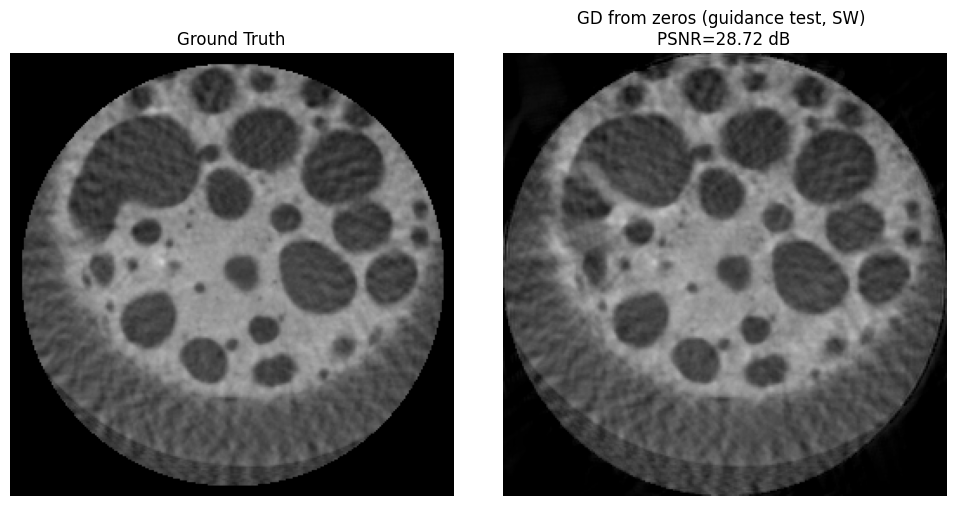

In [10]:
# Quick test: guidance from zero initialisation (uses SW projections since t=999 > threshold)
sw_gd = sinogram_guidance(
    projs_vrc=meas_projs,
    angles_deg=meas_angles,
    vol_init=torch.zeros(D, H, W, device=device),
    max_epochs=10,
    lr=0.5,
    batch_size=30,
    verbose=True,
    sw_projs_vrc=meas_sw_projs,
    sw_angles_deg=meas_sw_angles,
    timestep=999,
)
print(f"Guidance test output: {sw_gd.shape}")
psnr_sw_gd = masked_psnr(gt, sw_gd, circ_mask, data_range)
print(f"PSNR (SW guidance): {psnr_sw_gd:.2f} dB")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gt[TEST_SLICE_IDX].cpu().numpy(), cmap='gray', vmin=vmin, vmax=vmax)
axes[0].set_title('Ground Truth')
axes[0].axis('off')
axes[1].imshow(sw_gd[TEST_SLICE_IDX].cpu().numpy(), cmap='gray', vmin=vmin, vmax=vmax)
axes[1].set_title(f'GD from zeros (guidance test, SW) \nPSNR={psnr_sw_gd:.2f} dB')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## 8. Run DDIM Pipeline with Guidance

In [11]:
# Reload modules to pick up any recent edits
import ladiff.schedulers.scheduling_ddim  as _scheduling_ddim_mod
importlib.reload(_scheduling_ddim_mod)
import ladiff.schedulers.pipeline_ddim  as _pipeline_mod
importlib.reload(_pipeline_mod)
from ladiff.schedulers.scheduling_ddim import GuidedDDIMScheduler
from ladiff.schedulers.pipeline_ddim import DDIMPipeline



In [12]:
# ── Sliding-window guidance threshold ─────────────────────────────────────
# At diffusion timesteps > this value, guidance uses ALL frames' projections
# (sliding window). Below this threshold, only the middle frame's projections.
SW_GUIDANCE_TIMESTEP_THRESHOLD = 500

# Guidance hyperparameters
GUIDANCE_EPOCHS     = [1]
GUIDANCE_LR         = [0.005]
GUIDANCE_BATCH_SIZE = 150

# ── Regularization ─────────────────────────────────────────────────────────
# TV_WEIGHT_Z  > 0  → penalise differences between adjacent slices.
#                     This is the main knob for inter-slice consistency.
# TV_WEIGHT_XY > 0  → additionally penalise in-plane gradients.
#                     Leave at 0 to preserve in-plane sharpness.
TV_WEIGHT_Z  = 80.0
TV_WEIGHT_XY = 1.0
reg_fn = make_tv_regularizer(weight_z=TV_WEIGHT_Z, weight_xy=TV_WEIGHT_XY)

# Build the guidance lambda for the scheduler
# Input: (D, H, W) predicted x_0 in data space, t = current timestep
# At high t (noisy): use sliding-window (all frames)
# At low t (clean):  use middle frame only
guidance = lambda x, t: sinogram_guidance(
    projs_vrc=meas_projs,
    angles_deg=meas_angles,
    vol_init=x.to(device),
    max_epochs=GUIDANCE_EPOCHS,
    lr=GUIDANCE_LR,
    batch_size=GUIDANCE_BATCH_SIZE,
    regularization_fn=reg_fn,
    sw_projs_vrc=meas_sw_projs,
    sw_angles_deg=meas_sw_angles,
    timestep=int(t),
    sw_threshold=SW_GUIDANCE_TIMESTEP_THRESHOLD,
)

print(f"Guidance ready: {meas_projs.shape[0]} middle-frame projections, "
      f"{meas_sw_projs.shape[0]} sliding-window projections")
print(f"  {GUIDANCE_EPOCHS} GD epochs/step, lr={GUIDANCE_LR}")
print(f"  TV regularizer: weight_z={TV_WEIGHT_Z}, weight_xy={TV_WEIGHT_XY}")
print(f"  SW guidance for t > {SW_GUIDANCE_TIMESTEP_THRESHOLD}, middle-only for t ≤ {SW_GUIDANCE_TIMESTEP_THRESHOLD}")


Guidance ready: 200 middle-frame projections, 1000 sliding-window projections
  [1] GD epochs/step, lr=[0.005]
  TV regularizer: weight_z=80.0, weight_xy=1.0
  SW guidance for t > 500, middle-only for t ≤ 500


In [18]:
torch.cuda.empty_cache()
NUM_INFERENCE_STEPS = 50

noise_scheduler = GuidedDDIMScheduler(
    num_train_timesteps=1000,
    guidance_function=guidance,
)

pipeline = DDIMPipeline(
    unet=model.to(device),
    scheduler=noise_scheduler,
    fdk_prior=None,
    normalize_fn=normalize_fn,
    denormalize_fn=denormalize_fn,
    slice_batch_size=32,
)

t0 = time.time()
result = pipeline.truncated_pipeline(
    initial_guess=gt_vol.squeeze(),                   # start from the guided reconstruction (can also start from zeros or FBP)
    start_step=0,
    # batch_size=D,                       # single 2D slice: (1, H, W)
    num_inference_steps=NUM_INFERENCE_STEPS,
)
diffusion_recon = result.images.squeeze(0)  # (H, W)
dt = time.time() - t0
diffusion_recon *= circ_mask  # apply circular mask to final output

print(f"Guided DDIM reconstruction done in {dt:.1f}s")
print(f"  shape: {diffusion_recon.shape}")
print(f"  range: [{diffusion_recon.min():.4f}, {diffusion_recon.max():.4f}]")

  0%|          | 0/50 [00:00<?, ?it/s]

Guided DDIM reconstruction done in 49.8s
  shape: torch.Size([120, 256, 256])
  range: [0.0000, 0.7887]


## 9. Compare and Compute Metrics

Method                     PSNR (dB)     SSIM
---------------------------------------------
Guided DDIM                    21.85   0.6262
LA FBP                         11.53   0.3013
SW FBP                         22.05   0.8254
Full-angle FBP                 22.98   0.9295


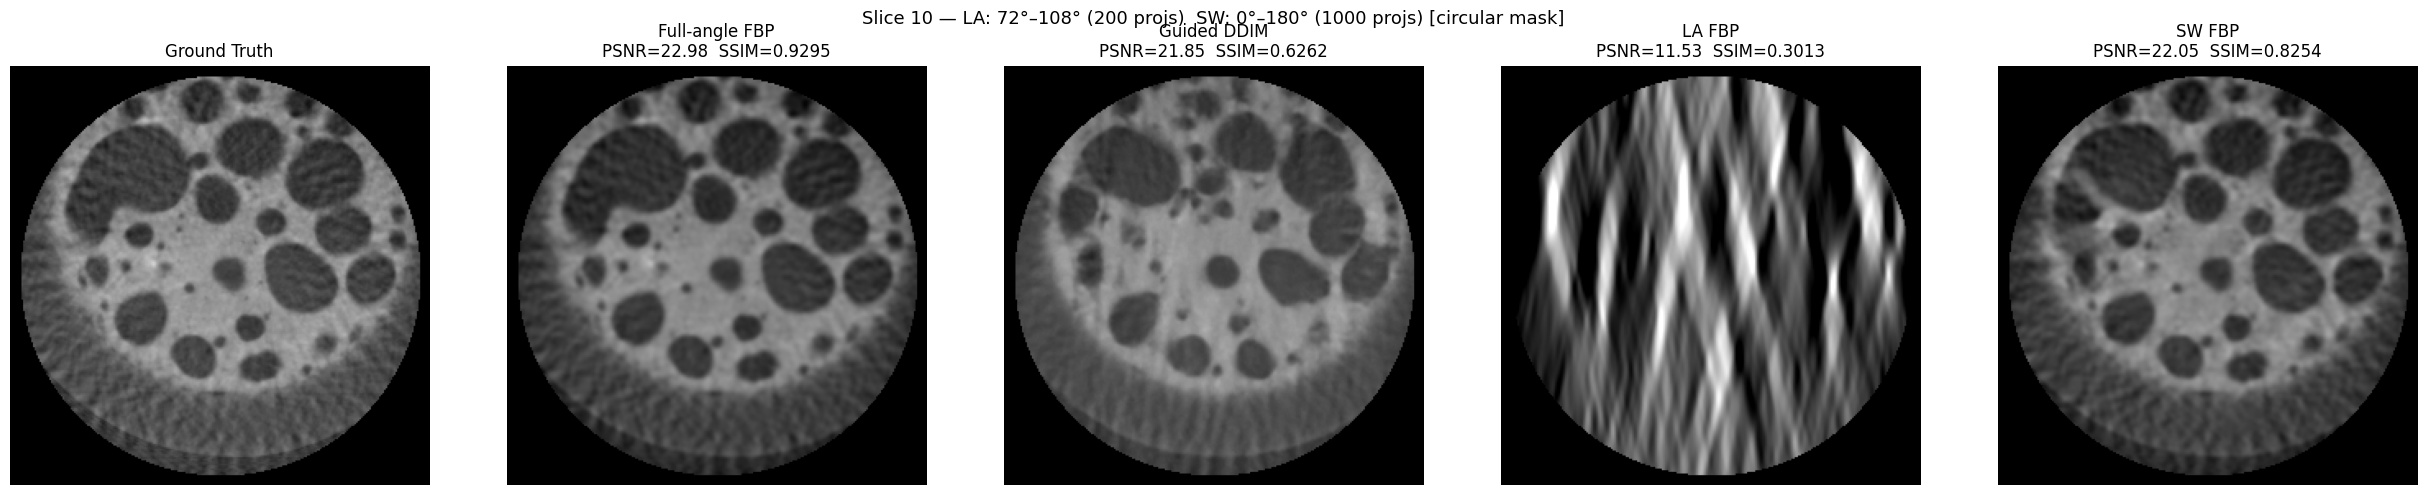

In [19]:
psnr_ddim = masked_psnr(gt, diffusion_recon, circ_mask, data_range)
ssim_ddim = masked_ssim(gt, diffusion_recon, circ_mask, data_range)
psnr_la   = masked_psnr(gt, la_fbp, circ_mask, data_range)
ssim_la   = masked_ssim(gt, la_fbp, circ_mask, data_range)
psnr_full = masked_psnr(gt, gt_fbp, circ_mask, data_range)
ssim_full = masked_ssim(gt, gt_fbp, circ_mask, data_range)
psnr_sw   = masked_psnr(gt, sw_fbp, circ_mask, data_range)
ssim_sw   = masked_ssim(gt, sw_fbp, circ_mask, data_range)

print(f"{'Method':<25} {'PSNR (dB)':>10} {'SSIM':>8}")
print("-" * 45)
print(f"{'Guided DDIM':<25} {psnr_ddim:>10.2f} {ssim_ddim:>8.4f}")
print(f"{'LA FBP':<25} {psnr_la:>10.2f} {ssim_la:>8.4f}")
print(f"{'SW FBP':<25} {psnr_sw:>10.2f} {ssim_sw:>8.4f}")
print(f"{'Full-angle FBP':<25} {psnr_full:>10.2f} {ssim_full:>8.4f}")

n_cols = 5 if num_frames > 1 else 4
fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5))
axes[0].imshow(gt[TEST_SLICE_IDX].cpu(), cmap='gray', vmin=vmin, vmax=vmax)
axes[0].set_title('Ground Truth')
axes[0].axis('off')

axes[1].imshow(gt_fbp[TEST_SLICE_IDX].cpu(), cmap='gray', vmin=vmin, vmax=vmax)
axes[1].set_title(f'Full-angle FBP\nPSNR={psnr_full:.2f}  SSIM={ssim_full:.4f}')
axes[1].axis('off')

axes[2].imshow(diffusion_recon[TEST_SLICE_IDX].cpu(), cmap='gray', vmin=vmin, vmax=vmax)
axes[2].set_title(f'Guided DDIM\nPSNR={psnr_ddim:.2f}  SSIM={ssim_ddim:.4f}')
axes[2].axis('off')

axes[3].imshow(la_fbp[TEST_SLICE_IDX].cpu(), cmap='gray', vmin=vmin, vmax=vmax)
axes[3].set_title(f'LA FBP\nPSNR={psnr_la:.2f}  SSIM={ssim_la:.4f}')
axes[3].axis('off')

if num_frames > 1:
    axes[4].imshow(sw_fbp[TEST_SLICE_IDX].cpu(), cmap='gray', vmin=vmin, vmax=vmax)
    axes[4].set_title(f'SW FBP\nPSNR={psnr_sw:.2f}  SSIM={ssim_sw:.4f}')
    axes[4].axis('off')

a_s, a_e = la_angles_deg[0], la_angles_deg[-1]
sw_s, sw_e = sw_angles_deg[0], sw_angles_deg[-1]
plt.suptitle(f'Slice {TEST_SLICE_IDX} — LA: {a_s:.0f}°–{a_e:.0f}° ({NUM_LA_PROJS} projs)  '
             f'SW: {sw_s:.0f}°–{sw_e:.0f}° ({len(sw_angles_deg)} projs) [circular mask]', fontsize=13)
plt.tight_layout()
plt.show()

In [20]:
from ipywidgets import interact, IntSlider

@interact(slice_idx=IntSlider(min=0, max=gt.shape[0]-1, step=1, value=gt.shape[0] // 2))
def update_slice(slice_idx):
    # Error maps
    fig, axes = plt.subplots(2, 3, figsize=(12, 12))

    axes[0, 0].imshow(diffusion_recon[slice_idx].cpu(), cmap='gray', vmin=vmin, vmax=vmax)
    axes[0, 0].set_title(f'Guided DDIM\nPSNR={psnr_ddim:.2f} dB')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(gt[slice_idx].cpu(), cmap='gray', vmin=vmin, vmax=vmax)
    axes[0, 1].set_title('Ground Truth')
    axes[0, 1].axis('off')

    axes[0, 2].imshow(sw_gd[slice_idx].cpu(), cmap='gray', vmin=vmin, vmax=vmax)
    axes[0, 2].set_title(f'SW FBP\nPSNR={psnr_sw_gd:.2f} dB')
    axes[0, 2].axis('off')
    

    axes[1, 0].imshow(la_fbp[slice_idx].cpu(), cmap='gray', vmin=vmin, vmax=vmax)
    axes[1, 0].set_title(f'LA FBP\nPSNR={psnr_la:.2f} dB')
    axes[1, 0].axis('off')
    
    err_la = gt - la_fbp
    err_ddim = gt - diffusion_recon
    err_range_ddim = max(abs(err_ddim.min()), abs(err_ddim.max()))

    axes[1, 1].imshow(err_la[slice_idx].cpu(), cmap='RdBu', vmin=-err_range_ddim, vmax=err_range_ddim)
    axes[1, 1].set_title('Error (GT − LA FBP)')
    axes[1, 1].axis('off')

    
    axes[1, 2].imshow(err_ddim[slice_idx].cpu(), cmap='RdBu', vmin=-err_range_ddim, vmax=err_range_ddim)
    axes[1, 2].set_title('Error (GT − DDIM)')
    axes[1, 2].axis('off')

    plt.suptitle(f'Error comparison — slice {slice_idx}', fontsize=13)
    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=60, description='slice_idx', max=119), Output()), _dom_classes=('widget-…

## 10. Grid Search: SW Threshold × TV Weight_z × Start Step

Sweep over:
- `SW_GUIDANCE_TIMESTEP_THRESHOLD` ∈ {0, 50, 100, 200} — timestep above which the sliding-window (multi-frame) projections are used.
- `TV_WEIGHT_Z` ∈ {20, 50, 100, 200} — inter-slice TV regularisation weight.
- `start_step` ∈ {20, 30, 40} — DDIM truncation: how many steps from the end to run (higher = more denoising).

Total: **4 × 4 × 3 = 48 runs**.

Results are ranked by PSNR and displayed as annotated heatmaps (one per `start_step` value).

In [16]:
# !pip install pandas

In [17]:
import itertools, pandas as pd

# ── Grid axes ──────────────────────────────────────────────────────────────
GS_SW_THRESHOLDS = [0, 50, 100, 200]
GS_TV_WEIGHTS_Z  = [20, 50, 100, 200]
GS_START_STEPS   = [20, 30, 40]
GS_TV_WEIGHT_XY  = TV_WEIGHT_XY          # keep fixed at the value set in cell 8

GS_GUIDANCE_EPOCHS     = GUIDANCE_EPOCHS
GS_GUIDANCE_LR         = GUIDANCE_LR
GS_GUIDANCE_BATCH_SIZE = GUIDANCE_BATCH_SIZE
GS_NUM_INFERENCE_STEPS = NUM_INFERENCE_STEPS

n_total = len(GS_SW_THRESHOLDS) * len(GS_TV_WEIGHTS_Z) * len(GS_START_STEPS)
print(f"Grid search: {len(GS_SW_THRESHOLDS)} SW thresholds × "
      f"{len(GS_TV_WEIGHTS_Z)} TV_z weights × "
      f"{len(GS_START_STEPS)} start steps = {n_total} runs")
print(f"  TV_WEIGHT_XY fixed at {GS_TV_WEIGHT_XY}")
print(f"  Guidance: {GS_GUIDANCE_EPOCHS} epoch(s), lr={GS_GUIDANCE_LR}, batch={GS_GUIDANCE_BATCH_SIZE}")
print(f"  Inference steps: {GS_NUM_INFERENCE_STEPS}")

ModuleNotFoundError: No module named 'pandas'

In [ ]:
gs_results = []   # list of dicts

combos = list(itertools.product(GS_SW_THRESHOLDS, GS_TV_WEIGHTS_Z, GS_START_STEPS))
for run_idx, (sw_thr, tv_z_w, ss) in enumerate(combos):
    print(f"\n[{run_idx+1:02d}/{n_total}] sw_thr={sw_thr}, tv_z={tv_z_w}, start_step={ss}")

    # Build regulariser for this combination
    _reg_fn = make_tv_regularizer(weight_z=tv_z_w, weight_xy=GS_TV_WEIGHT_XY)

    # Guidance lambda
    _guidance = lambda x, t, _sw=sw_thr, _reg=_reg_fn: sinogram_guidance(
        projs_vrc=meas_projs,
        angles_deg=meas_angles,
        vol_init=x.to(device),
        max_epochs=GS_GUIDANCE_EPOCHS,
        lr=GS_GUIDANCE_LR,
        batch_size=GS_GUIDANCE_BATCH_SIZE,
        regularization_fn=_reg,
        sw_projs_vrc=meas_sw_projs,
        sw_angles_deg=meas_sw_angles,
        timestep=int(t),
        sw_threshold=_sw,
    )

    torch.cuda.empty_cache()
    _scheduler = GuidedDDIMScheduler(
        num_train_timesteps=1000,
        guidance_function=_guidance,
    )
    _pipeline = DDIMPipeline(
        unet=model.to(device),
        scheduler=_scheduler,
        fdk_prior=None,
        normalize_fn=normalize_fn,
        denormalize_fn=denormalize_fn,
        slice_batch_size=32,
    )

    t_start = time.time()
    _result = _pipeline.truncated_pipeline(
        initial_guess=sw_gd,
        start_step=ss,
        num_inference_steps=GS_NUM_INFERENCE_STEPS,
    )
    _recon = _result.images.squeeze(0)  # (D, H, W)
    _recon = _recon * circ_mask

    _psnr = masked_psnr(gt, _recon, circ_mask, data_range).item()
    _ssim = masked_ssim(gt, _recon, circ_mask, data_range)
    dt_run = time.time() - t_start

    print(f"  PSNR={_psnr:.3f} dB   SSIM={_ssim:.4f}   ({dt_run:.0f}s)")

    gs_results.append({
        'sw_thr':     sw_thr,
        'tv_z':       tv_z_w,
        'start_step': ss,
        'psnr':       _psnr,
        'ssim':       _ssim,
        'recon':      _recon.cpu(),   # store on CPU to save GPU memory
    })

print("\n\n=== Grid search complete ===")
df = pd.DataFrame([{k: v for k, v in r.items() if k != 'recon'} for r in gs_results])

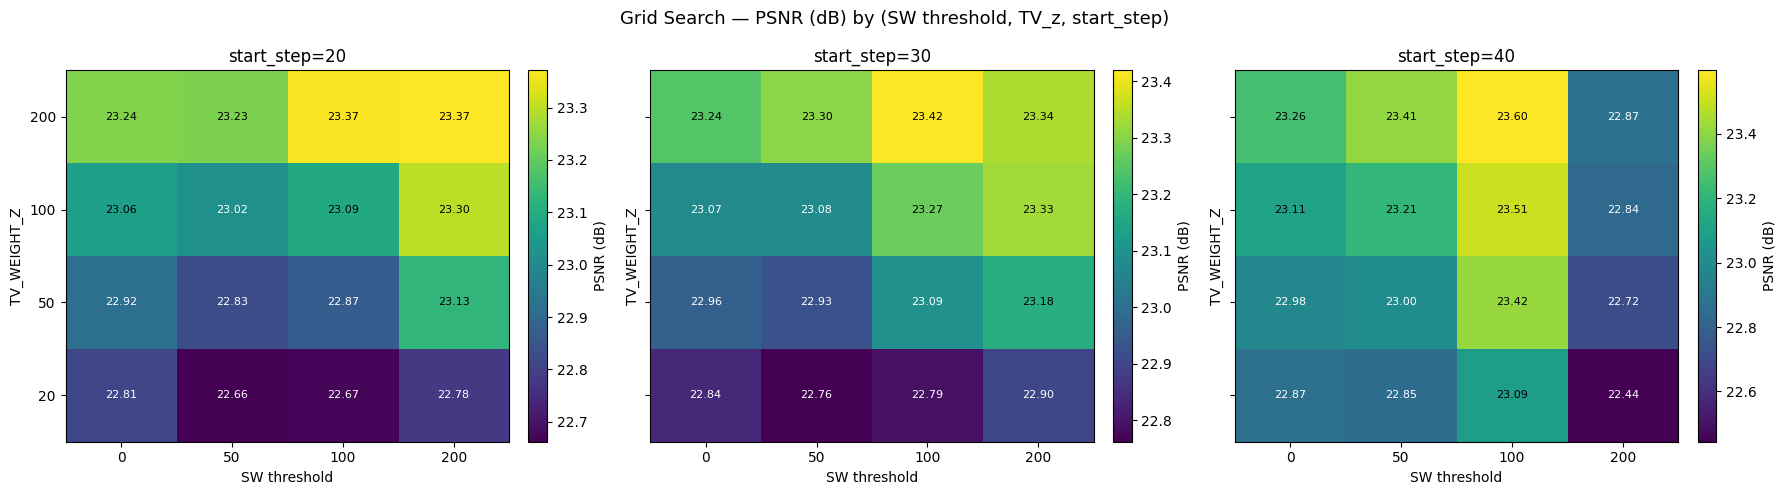

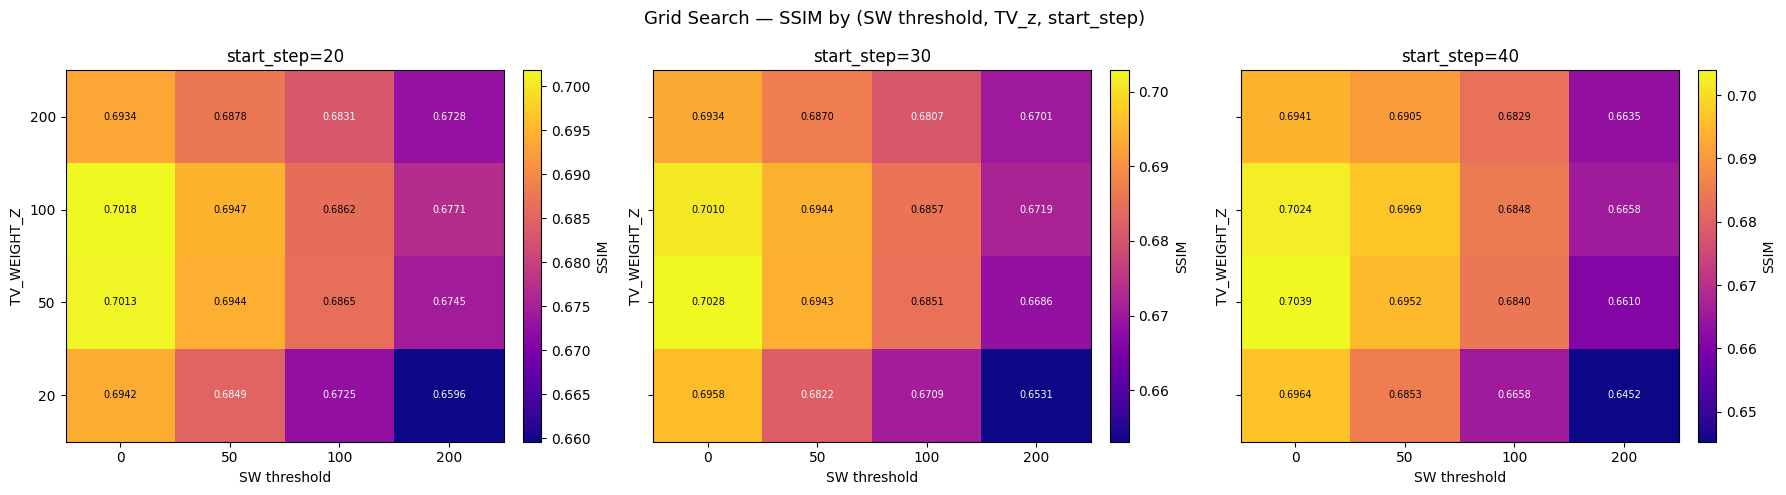


Top 10 configurations by PSNR:
 sw_thr  tv_z  start_step      psnr     ssim
      0    50          40 22.983530 0.703933
      0    50          30 22.962784 0.702839
      0   100          40 23.108822 0.702369
      0   100          20 23.061420 0.701827
      0    50          20 22.919941 0.701337
      0   100          30 23.074142 0.700951
     50   100          40 23.205772 0.696896
      0    20          40 22.869038 0.696431
      0    20          30 22.836485 0.695769
     50    50          40 23.003632 0.695230


In [ ]:
import matplotlib.ticker as ticker

# ── PSNR heatmaps: one subplot per start_step ──────────────────────────────
fig, axes = plt.subplots(1, len(GS_START_STEPS),
                         figsize=(6 * len(GS_START_STEPS), 5), sharey=True)
if len(GS_START_STEPS) == 1:
    axes = [axes]

for ax, ss in zip(axes, GS_START_STEPS):
    sub = df[df['start_step'] == ss].pivot(index='tv_z', columns='sw_thr', values='psnr')
    sub = sub.reindex(index=sorted(sub.index, reverse=True))   # largest tv_z on top
    im = ax.imshow(sub.values, cmap='viridis', aspect='auto')
    ax.set_xticks(range(len(sub.columns)))
    ax.set_xticklabels(sub.columns.tolist())
    ax.set_yticks(range(len(sub.index)))
    ax.set_yticklabels(sub.index.tolist())
    ax.set_xlabel('SW threshold')
    ax.set_ylabel('TV_WEIGHT_Z')
    ax.set_title(f'start_step={ss}')
    plt.colorbar(im, ax=ax, label='PSNR (dB)', fraction=0.046, pad=0.04)
    # Annotate cells
    for r in range(sub.shape[0]):
        for c in range(sub.shape[1]):
            ax.text(c, r, f'{sub.values[r, c]:.2f}',
                    ha='center', va='center', fontsize=8,
                    color='white' if sub.values[r, c] < sub.values.mean() else 'black')

fig.suptitle('Grid Search — PSNR (dB) by (SW threshold, TV_z, start_step)', fontsize=13)
plt.tight_layout()
plt.show()

# ── SSIM heatmaps ──────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, len(GS_START_STEPS),
                            figsize=(6 * len(GS_START_STEPS), 5), sharey=True)
if len(GS_START_STEPS) == 1:
    axes2 = [axes2]

for ax, ss in zip(axes2, GS_START_STEPS):
    sub = df[df['start_step'] == ss].pivot(index='tv_z', columns='sw_thr', values='ssim')
    sub = sub.reindex(index=sorted(sub.index, reverse=True))
    im = ax.imshow(sub.values, cmap='plasma', aspect='auto')
    ax.set_xticks(range(len(sub.columns)))
    ax.set_xticklabels(sub.columns.tolist())
    ax.set_yticks(range(len(sub.index)))
    ax.set_yticklabels(sub.index.tolist())
    ax.set_xlabel('SW threshold')
    ax.set_ylabel('TV_WEIGHT_Z')
    ax.set_title(f'start_step={ss}')
    plt.colorbar(im, ax=ax, label='SSIM', fraction=0.046, pad=0.04)
    for r in range(sub.shape[0]):
        for c in range(sub.shape[1]):
            ax.text(c, r, f'{sub.values[r, c]:.4f}',
                    ha='center', va='center', fontsize=7,
                    color='white' if sub.values[r, c] < sub.values.mean() else 'black')

fig2.suptitle('Grid Search — SSIM by (SW threshold, TV_z, start_step)', fontsize=13)
plt.tight_layout()
plt.show()

# ── Summary table (top 10 by PSNR) ─────────────────────────────────────────
print("\nTop 10 configurations by PSNR:")
print(df_sorted.head(10).to_string(index=False))

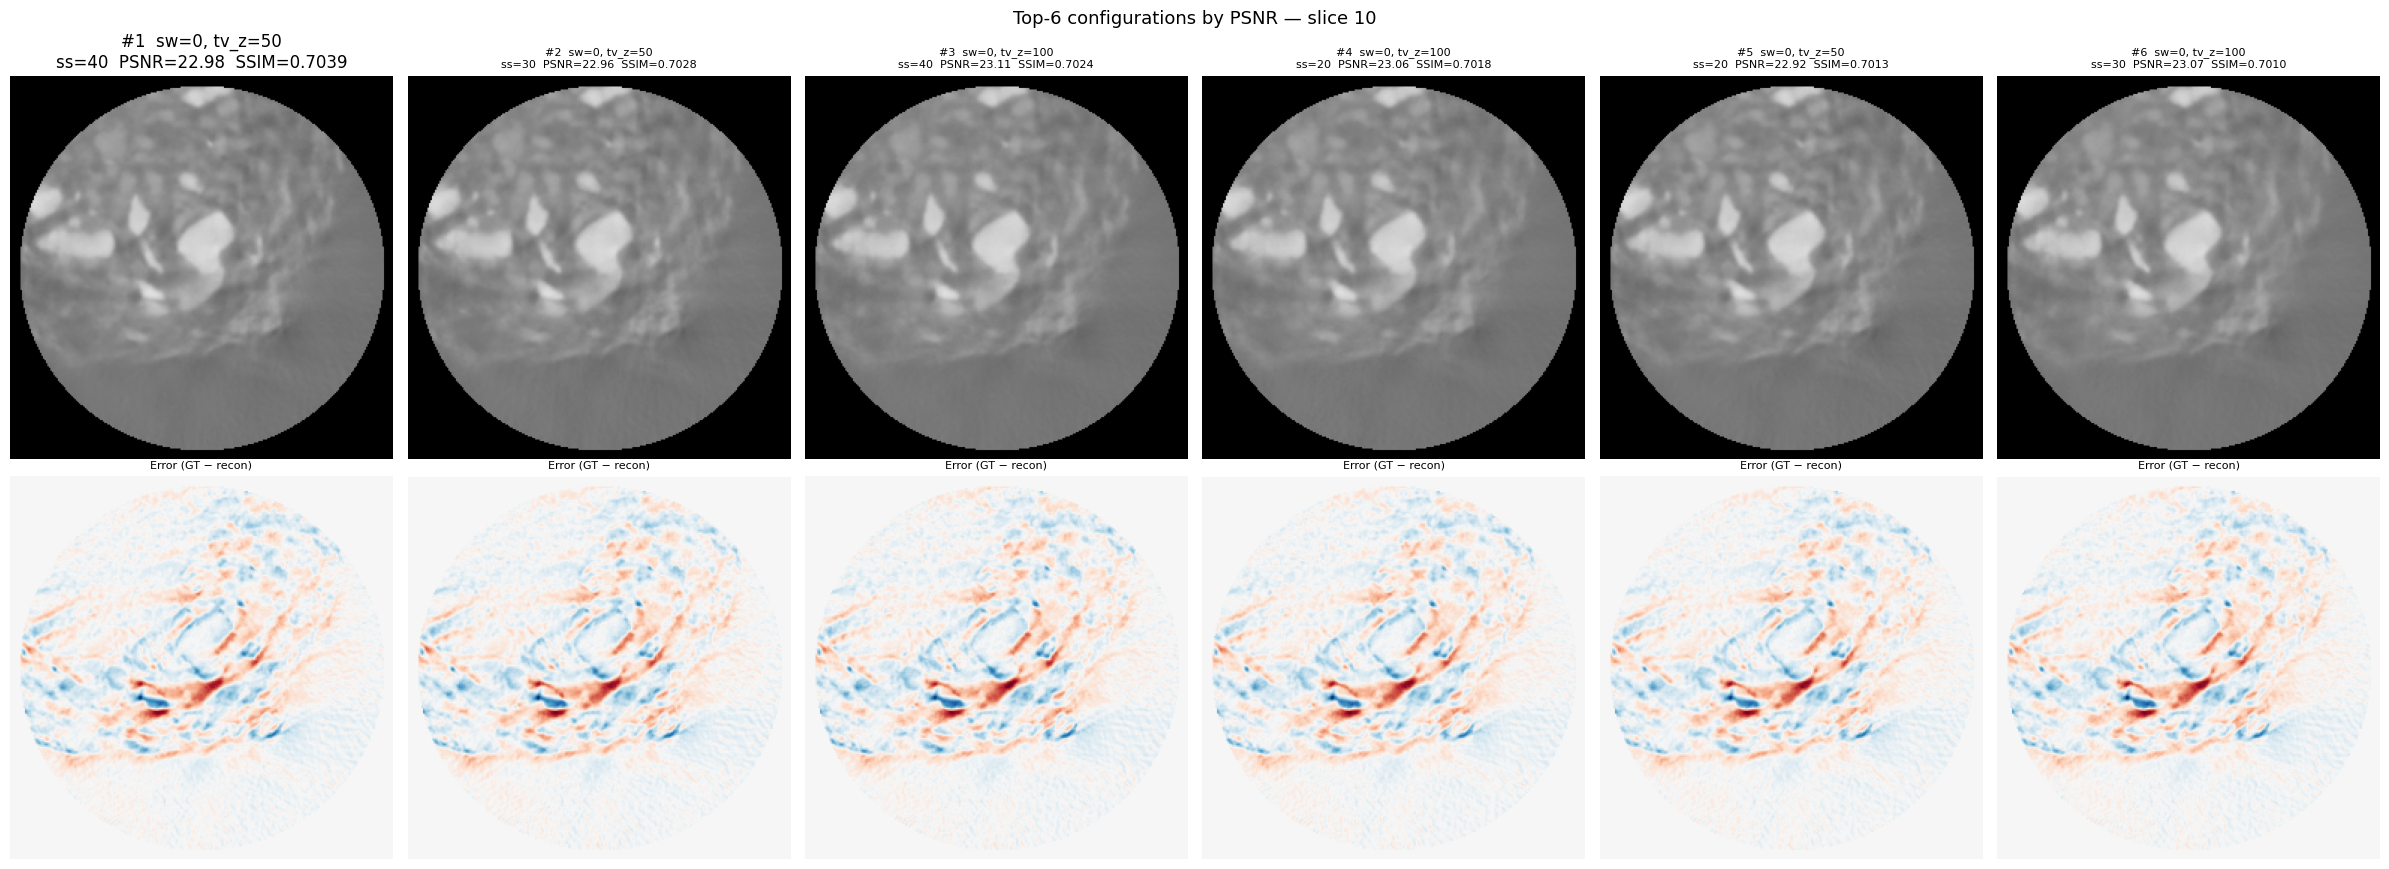

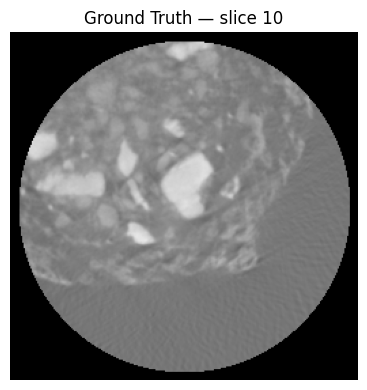

In [ ]:
from ipywidgets import interact, IntSlider, Dropdown

# ── Top-N qualitative comparison at TEST_SLICE_IDX ─────────────────────────
TOP_N = 6   # show best N configurations side-by-side

top_rows = df_sorted.head(TOP_N)
fig, axes = plt.subplots(2, TOP_N, figsize=(4 * TOP_N, 9))

for col, (_, row) in enumerate(top_rows.iterrows()):
    _entry = next(r for r in gs_results
                  if r['sw_thr'] == row['sw_thr']
                  and r['tv_z'] == row['tv_z']
                  and r['start_step'] == row['start_step'])
    _img = _entry['recon'][TEST_SLICE_IDX].numpy()
    _err = (gt[TEST_SLICE_IDX].cpu() - _entry['recon'][TEST_SLICE_IDX]).numpy()
    err_lim = max(abs(_err.min()), abs(_err.max()))

    axes[0, col].imshow(_img, cmap='gray', vmin=vmin, vmax=vmax)
    axes[0, col].set_title(
        f"#{ col+1 }  sw={int(row['sw_thr'])}, tv_z={int(row['tv_z'])}\n"
        f"ss={int(row['start_step'])}  PSNR={row['psnr']:.2f}  SSIM={row['ssim']:.4f}",
        fontsize=8)
    axes[0, col].axis('off')

    axes[1, col].imshow(_err, cmap='RdBu', vmin=-err_lim, vmax=err_lim)
    axes[1, col].set_title(f'Error (GT − recon)', fontsize=8)
    axes[1, col].axis('off')

# Ground truth reference inset
axes[0, 0].set_title(axes[0, 0].get_title())  # keep existing title
fig.suptitle(
    f'Top-{TOP_N} configurations by PSNR — slice {TEST_SLICE_IDX}', fontsize=13)
plt.tight_layout()
plt.show()

# ── Ground truth alongside for reference ───────────────────────────────────
fig_gt, ax_gt = plt.subplots(1, 1, figsize=(4, 4))
ax_gt.imshow(gt[TEST_SLICE_IDX].cpu().numpy(), cmap='gray', vmin=vmin, vmax=vmax)
ax_gt.set_title(f'Ground Truth — slice {TEST_SLICE_IDX}')
ax_gt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Interactive viewer: browse all grid-search results across slices
_gs_options = [
    (f"#{i+1}  sw={r['sw_thr']} tv_z={r['tv_z']} ss={r['start_step']}  "
     f"PSNR={r['psnr']:.2f}", i)
    for i, r in enumerate(sorted(gs_results, key=lambda x: -x['psnr']))
]

@interact(
    config_rank=Dropdown(
        options=_gs_options,
        description='Config (ranked):',
        layout={'width': '500px'},
        style={'description_width': '140px'},
    ),
    slice_idx=IntSlider(min=0, max=gt.shape[0]-1, step=1,
                        value=TEST_SLICE_IDX, description='Slice'),
)
def _gs_viewer(config_rank, slice_idx):
    _sorted = sorted(gs_results, key=lambda x: -x['psnr'])
    row = _sorted[config_rank]
    _recon = row['recon']
    _err   = gt[slice_idx].cpu() - _recon[slice_idx]
    err_lim = max(abs(_err.min()), abs(_err.max()))

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))

    axes[0].imshow(gt[slice_idx].cpu().numpy(), cmap='gray', vmin=vmin, vmax=vmax)
    axes[0].set_title('Ground Truth')
    axes[0].axis('off')

    axes[1].imshow(_recon[slice_idx].numpy(), cmap='gray', vmin=vmin, vmax=vmax)
    axes[1].set_title(
        f"Grid result (PSNR={row['psnr']:.2f} dB)\n"
        f"sw_thr={row['sw_thr']}, tv_z={row['tv_z']}, start_step={row['start_step']}")
    axes[1].axis('off')

    axes[2].imshow(la_fbp[slice_idx].cpu().numpy(), cmap='gray', vmin=vmin, vmax=vmax)
    axes[2].set_title(f'LA FBP  (PSNR={psnr_la:.2f} dB)')
    axes[2].axis('off')

    axes[3].imshow(_err.numpy(), cmap='RdBu', vmin=-err_lim, vmax=err_lim)
    axes[3].set_title('Error (GT − grid result)')
    axes[3].axis('off')

    plt.suptitle(f'Slice {slice_idx}', fontsize=12)
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='Config (ranked):', layout=Layout(width='500px'), options=(('#1  sw…